
# <!-- TITLE --> A first GAN to Draw a Sheep
<!-- DESC --> Part 1: Draw me a sheep, revisited with a DCGAN

## Objectives :
 - Build and train a DCGAN model with the Quick Draw dataset
 - Understanding DCGAN

The [Quick draw dataset](https://quickdraw.withgoogle.com/data) contains about 50.000.000 drawings, made by real people...  
We are using a subset of 117.555 of Sheep drawings  
To get the dataset : [https://github.com/googlecreativelab/quickdraw-dataset](https://github.com/googlecreativelab/quickdraw-dataset)  
Datasets in numpy bitmap file : [https://console.cloud.google.com/storage/quickdraw_dataset/full/numpy_bitmap](https://console.cloud.google.com/storage/quickdraw_dataset/full/numpy_bitmap)   
Sheep dataset : [https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sheep.npy](https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sheep.npy) (94.3 Mo)


## What we're going to do :

 - Have a look to the dataset
 - Defining a GAN model
 - Build the model
 - Train it
 - Analyze the results

## Acknowledgements :
Thanks to **François Chollet** who is at the base of this example.  
See : [https://keras.io/examples/](https://keras.io/examples/)


<img width="800px" src="./img/sheep1.png"></img>

## Step 1 - Init python stuff

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import sys

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import TensorBoard

from modules.models    import DCGAN
from modules.callbacks import ImagesCallback

import fidle

## Step 2 - Parameters
`scale` : With scale=1, we need 5-6 minutes on a GPU V100 ...and >2h on a CPU !  
`latent_dim` : Latent space dimension, 128 for example !  
`fit_verbosity` : verbosity during training : 0 = silent, 1 = progress bar, 2 = one line per epoch  
`num_img` : Number of images to visualize

**Notes:** 
- The settings below (scale=0.01, epochs=5) allow the notebooks to run on a laptop, but not to get a minimal result!
- For a decent result, you need something like: scale=1, epochs=10

In [17]:
latent_dim    = 128

scale         = .01
epochs        = 5
batch_size    = 32
num_img       = 12
fit_verbosity = 1

## Step 3 - Load dataset and have a look 
Load sheeps as numpy bitmaps...

In [18]:
# download the sheep dataset
import os
import requests

# URL of the sheep dataset (bitmap format)
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/sheep.npy"

# Where to save
output_dir = "quickdraw_data"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "sheep.npy")

# Download file
print("Downloading sheep dataset...")

response = requests.get(url, stream=True)

with open(file_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Download finished!")
print("Saved at:", file_path)

Download finished!
Saved at: quickdraw_data\sheep.npy


In [ ]:
# Load dataset
x_data = np.load('./quickdraw_data/sheep.npy')
print('Original dataset shape : ',x_data.shape)

# Rescale
n=int(scale*len(x_data))
x_data = x_data[:n]
print('Rescaled dataset shape : ',x_data.shape)

# Normalize, reshape and shuffle
x_data = x_data/255 # marche car blanc ou noir
x_data = x_data.reshape(-1,28,28,1)# reshape 1D-> 2D
np.random.shuffle(x_data)
print('Final dataset shape    : ',x_data.shape)


Original dataset shape :  (126121, 784)
Rescaled dataset shape :  (1261, 784)
Final dataset shape    :  (1261, 28, 28, 1)


...and have a look :  
Note : These sheep are sheep drawn ... by real humans!

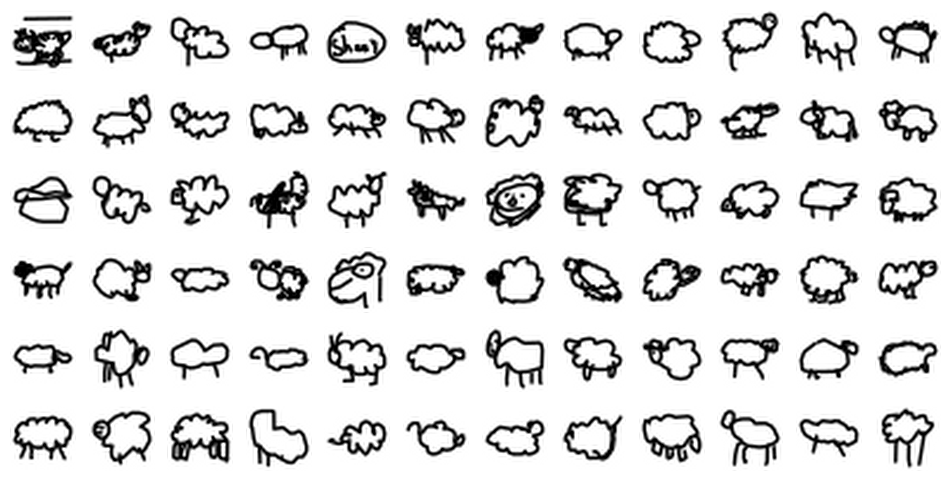

In [20]:
fidle.scrawler.images( x_data.reshape(-1,28,28), indices=range(72), columns=12, x_size=1, y_size=1, 
                       y_padding=0,spines_alpha=0)

## Step 4 - Create a discriminator

In [ ]:
inputs  = keras.Input(shape=(28, 28, 1))
#leakyRelu pour améliorer cv opti
x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
#alpha choisi comme ça, pas de raison 
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#augmente kernel_size-> picture + grande ?
#strides 2 au lieu de maxpooling
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)
x       = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x) 
# pk préciser pente LeakyRelu ?
z       = layers.Dense(1, activation="sigmoid")(x) # pk pas heavyside: indicatrice oui ou non ?
# Stride = 2 to downsample
# padding = "same" to keep the output size the same as input size
# (except for the last layer)

discriminator = keras.Model(inputs, z, name="discriminator")
discriminator.summary()

c:\Users\admin\Desktop\GEN ai\TP-3\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,609 (1.51 MB)

 Trainable params: 396,609 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 - Create a generator

In [ ]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64)(inputs) # random choice ?
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.UpSampling2D()(x)   #pk upsampling au lieu de conv2dtranspose ?
x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
x       = layers.UpSampling2D()(x)
x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)
#  sigmoid to get output in [0,1] range (because of the normalization of the input images)

# here we use UpSampling2D + Conv2D (to mix the features) instead of Conv2DTranspose
# to avoid checkerboard artifacts

generator = keras.Model(inputs, outputs, name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │         6,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 779,969 (2.98 MB)

 Trainable params: 779,969 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Build, compile and train our DCGAN 
First, clean saved images :

In [23]:
# !rm $run_dir/images/*.jpg >/dev/null 2>&1 
run_dir = './runs/01-DCGAN-Draw-me-a-sheep'

Build our model :

In [24]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

Fidle DCGAN is ready :-)  latent dim = 128


In [25]:
gan.compile(
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001),
    loss_function           = keras.losses.BinaryCrossentropy(),
)

Add a callback to save images, train our DCGAN model and save it :

In [26]:
imagesCallback = ImagesCallback(num_img=num_img, latent_dim=latent_dim, run_dir=f'{run_dir}/images')

history = gan.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

gan.save(f'{run_dir}/models/model.h5')

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 524ms/step - d_loss: 0.5374 - g_loss: 0.7315
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 478ms/step - d_loss: 0.3700 - g_loss: 1.2655
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 545ms/step - d_loss: 0.3154 - g_loss: 0.8021
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 523ms/step - d_loss: 0.2059 - g_loss: 1.1429
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 578ms/step - d_loss: 0.0511 - g_loss: 2.6770


## Step 7 - History

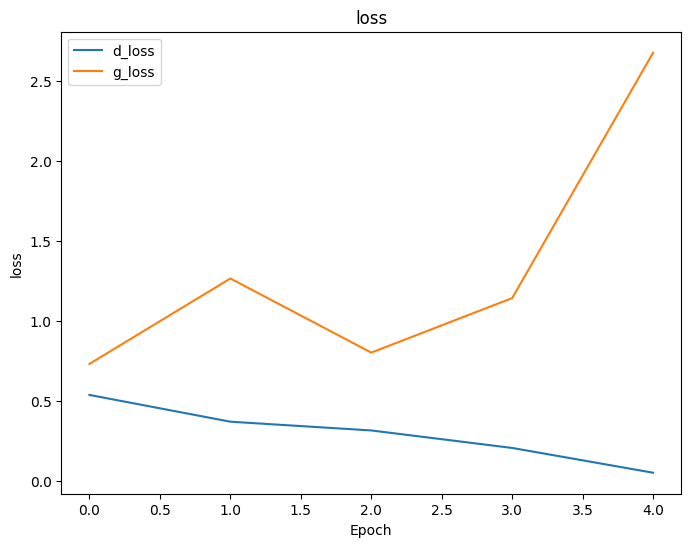

In [27]:
fidle.scrawler.history(history,  plot={'loss':['d_loss','g_loss']}, save_as='01-history')

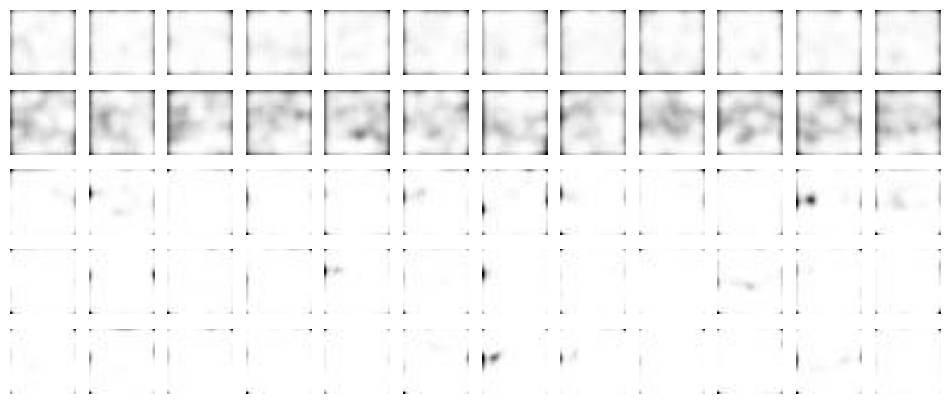

In [28]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')

## Step 8 - Generation
Reload our saved model :

In [29]:
gan.reload(f'{run_dir}/models/model.h5')

Reloaded.


Generate somes images from latent space :

In [30]:
nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan.predict(z, verbose=0)


Plot it :

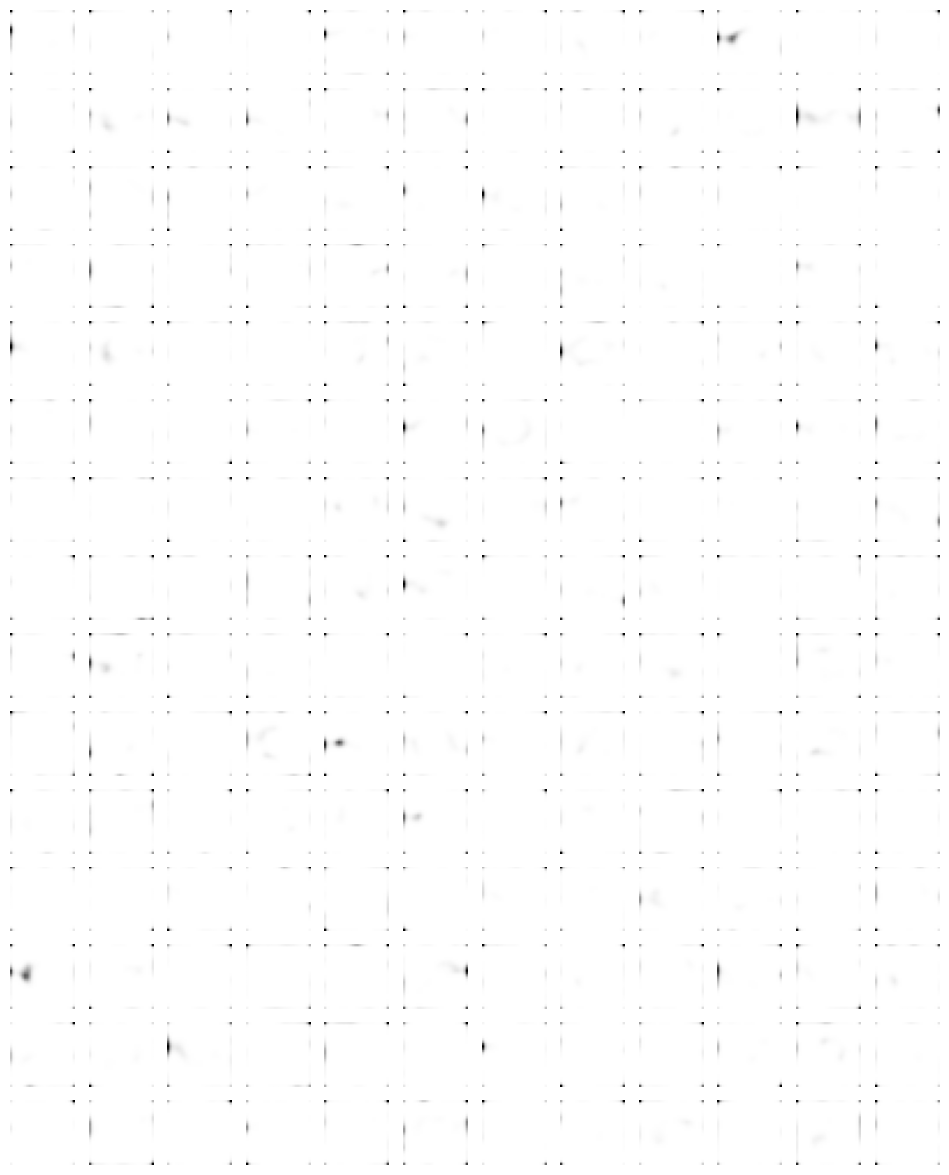

In [31]:
fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')